In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [3]:
df = pd.read_csv("../data/processed/yellow_tripdata_2025-01.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2795902 entries, 0 to 2795901
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   trip_distance          float64
 2   PULocationID           int64  
 3   DOLocationID           int64  
 4   fare_amount            float64
 5   extra                  float64
 6   mta_tax                float64
 7   tip_amount             float64
 8   tolls_amount           float64
 9   improvement_surcharge  float64
 10  congestion_surcharge   float64
 11  Airport_fee            float64
 12  cbd_congestion_fee     float64
 13  duration_min           float64
dtypes: float64(11), int64(3)
memory usage: 298.6 MB


In [4]:
X = df.drop(columns="duration_min")
y = df["duration_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)
model = RandomForestRegressor(n_estimators=10, min_samples_leaf=50)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
df["duration_min"].describe()

count    2.795902e+06
mean     1.462744e+01
std      1.170012e+01
min      1.000000e+00
25%      7.100000e+00
50%      1.138000e+01
75%      1.815000e+01
max      1.799700e+02
Name: duration_min, dtype: float64

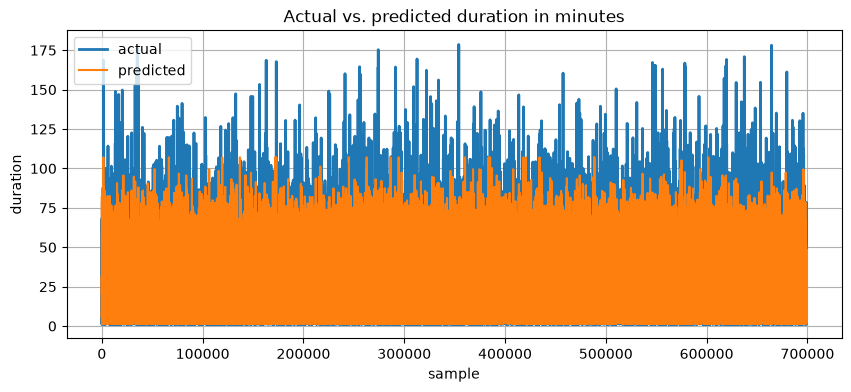

,actual,predicted
0,22.02,21.018629
1,21.40,21.255912
2,18.72,19.010840
3,35.58,31.561532
4,5.73,5.838702


In [6]:
comparison_df = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted": y_pred,
    }
).reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(comparison_df.index, comparison_df["actual"], label="actual", linewidth=2)
plt.plot(
    comparison_df.index,
    comparison_df["predicted"],
    label="predicted",
    linewidth=1.5,
)
plt.title("Actual vs. predicted duration in minutes")
plt.xlabel("sample")
plt.ylabel("duration")
plt.legend()
plt.grid(True)
plt.show()

comparison_df.head()

In [7]:
comparison_df = comparison_df.assign(
    residual=comparison_df["actual"] - comparison_df["predicted"],
    absolute_error=(comparison_df["actual"] - comparison_df["predicted"]).abs(),
)

comparison_df.sort_values("absolute_error", ascending=False).head()

,actual,predicted,residual,absolute_error
354100,178.63,12.899126,165.730874,165.730874
664394,178.17,25.695607,152.474393,152.474393
36256,162.90,16.889282,146.010718,146.010718
653361,154.65,10.878093,143.771907,143.771907
473297,143.87,6.349992,137.520008,137.520008


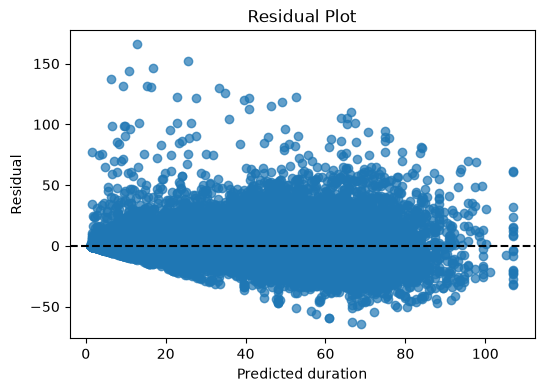

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(comparison_df["predicted"], comparison_df["residual"], alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted duration")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [9]:

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:,.0f}")


MAE: 1


In [10]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:,.0f}")

MSE: 12


In [11]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:,.0f}")

RMSE: 4


In [12]:
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

R²: 0.910


In [13]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.2%}")

MAPE: 8.45%


In [14]:
pd.DataFrame(
    {
        "metric": ["MAE", "MSE", "RMSE", "R²", "MAPE"],
        "value": [mae, mse, rmse, r2, mape],
        "what_it_emphasizes": [
            "Typical absolute error",
            "Large errors are penalized strongly",
            "Large errors, but back in target units",
            "Explained variance",
            "Relative error in percentage terms",
        ],
    }
)

,metric,value,what_it_emphasizes
0,MAE,1.340090,Typical absolute error
1,MSE,12.371719,Large errors are penalized strongly
2,RMSE,3.517345,"Large errors, but back in target units"
3,R²,0.909965,Explained variance
4,MAPE,0.084511,Relative error in percentage terms


In [15]:
import mlflow
from mlflow.models import infer_signature
import logging
import os
from datetime import UTC, datetime
from pathlib import Path

#import mlflow
#import pandas as pd
from dotenv import load_dotenv
from mlflow import MlflowClient
from mlflow.exceptions import MlflowException
from sklearn.compose import ColumnTransformer
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_absolute_error
#from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
#from sklearn.preprocessing import OneHotEncoder

logging.getLogger("mlflow.utils").setLevel(logging.ERROR)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / ".env").exists() else Path.cwd().parent
load_dotenv(dotenv_path=PROJECT_ROOT / ".env")

#print(PROJECT_ROOT)

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
REGISTERED_MODEL_NAME = os.getenv("REGISTERED_MODEL_NAME", "rf-taxi-duration")
MODEL_ALIAS = os.getenv("MODEL_ALIAS", "production")

print(
    {
        "tracking_uri": MLFLOW_TRACKING_URI,
        "registered_model_name": REGISTERED_MODEL_NAME,
        "model_alias": MODEL_ALIAS,
    }
)

#from config import SOLUTION_ROOT

# Keep the MLflow database and saved models in the project root, wherever the notebook runs from
#mlflow.set_tracking_uri(f"sqlite:///{SOLUTION_ROOT / 'mlflow.db'}")

#EXPERIMENT_NAME = "nyc-taxi-duration"
#if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
#    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=(SOLUTION_ROOT / "mlruns").as_uri())
#mlflow.set_experiment(EXPERIMENT_NAME)




{'tracking_uri': 'http://127.0.0.1:5000', 'registered_model_name': 'rf-taxi-duration', 'model_alias': 'production'}


In [16]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Yellow-taxi-duration-demo")


with mlflow.start_run(run_name="random-forest") as run:
    mlflow.log_params(model.get_params())
    #mlflow.log_param("n_train_rows", len(X_train))

    mlflow.log_metrics({"mae": mae, "mse": mse, "rmse": rmse, "r2": r2, "mape": mape})

    model_info = mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
        signature=infer_signature(X_test, y_pred),
        input_example=X_test.head(3),
        skops_trusted_types=["sklearn.tree._tree.Tree"],
    )
    run_id = run.info.run_id

print({"run_id": run_id, "tracking_uri": mlflow.get_tracking_uri()})


/home/localadmin/BOOT_CAMP_exercise/module_3/ML_model_deployment/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run random-forest at: http://127.0.0.1:5000/#/experiments/1/runs/8a6b4da2730b429181c79a526be082d5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
{'run_id': '8a6b4da2730b429181c79a526be082d5', 'tracking_uri': 'http://127.0.0.1:5000'}


In [17]:
client = MlflowClient()

try:
    client.create_registered_model(
        name=REGISTERED_MODEL_NAME,
        tags={"framework": "scikit-learn"},
        description="Demo model for the local FastAPI deployment workflow.",
    )
    print("Created registered model.")
except MlflowException as error:
    # Reuse the model only if it already exists; re-raise any other MLflow error.
    if error.error_code != "RESOURCE_ALREADY_EXISTS":
        raise
    print("Registered model already exists. Reusing it.")

model_version = client.create_model_version(
    name=REGISTERED_MODEL_NAME,
    source=model_info.model_uri,
    run_id=run_id,
)

print({"version": model_version.version})

2026/10/01 17:41:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rf-taxi-duration, version 1


Created registered model.
{'version': '1'}


In [18]:
client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias=MODEL_ALIAS,
    version=model_version.version,
)

client.update_model_version(
    name=REGISTERED_MODEL_NAME,
    version=model_version.version,
    description=f"Promoted locally on {datetime.now(tz=UTC).date()} for the FastAPI demo.",
)

print({"alias": MODEL_ALIAS, "version": model_version.version})

{'alias': 'production', 'version': '1'}
